# RPA many-body response functions, for interactions beyond onsite

`h.get_spinchi_ladder`/`h.get_spinchi_full` (spin channel) and `h.get_densitychi_RPA` (density/charge
channel) dress the bare susceptibility of a mean-field Hamiltonian with the random phase
approximation, $\chi_{RPA}=\chi(1-U\chi)^{-1}$, using the interaction matrix stored on `h.V` after
convergence -- not restricted to a single onsite $U$: `h.V`/the `V=` argument can be a real-space
hopping-like dictionary $\{(n_1,n_2,n_3)\!:\!\text{matrix}\}$, so a neighbor-shell exchange ($J_1$)
or density-density interaction ($V_1$) is Fourier-transformed to $V(q)$ and dressed exactly like an
extended hopping. Below, RPA strongly enhances the spin response of an antiferromagnetic chain
relative to the bare (non-interacting) response.

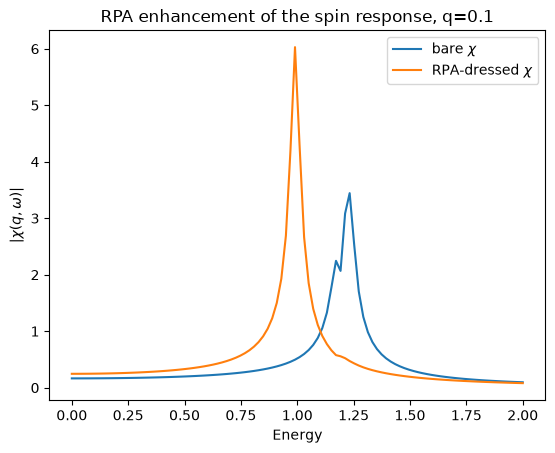

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.chain()
h = g.get_hamiltonian(has_spin=True)
hmf = h.get_mean_field_hamiltonian(U=2.0,filling=0.5,mf="antiferro")

energies = np.linspace(0.,2.,100)
(es,chi_rpa) = hmf.get_spinchi_ladder(energies=energies,q=[0.1,0.,0.],nk=40,delta=2e-2,RPA=True)
(es,chi_bare) = hmf.get_spinchi_ladder(energies=energies,q=[0.1,0.,0.],nk=40,delta=2e-2,RPA=False)
chi_rpa = np.array(chi_rpa)[:,0,0] # squeeze the (1x1) component matrix
chi_bare = np.array(chi_bare)[:,0,0]

plt.plot(es,np.abs(chi_bare),label="bare $\chi$")
plt.plot(es,np.abs(chi_rpa),label="RPA-dressed $\chi$")
plt.xlabel("Energy") ; plt.ylabel("$|\chi(q,\omega)|$")
plt.legend()
plt.title("RPA enhancement of the spin response, q=0.1")
plt.show()